<a href="https://colab.research.google.com/github/NiranjanHebli/cat-vs-astronaut-cnn/blob/main/Astronaut_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install torch torchvision matplotlib pillow

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform

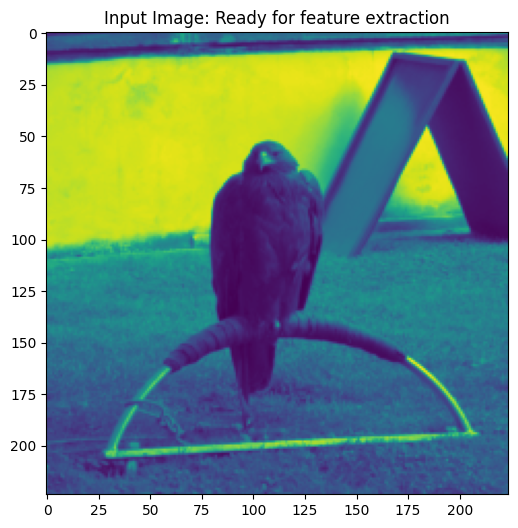

In [ ]:
img_raw = data.eagle()
img_raw = transform.resize(img_raw, (224, 224))

plt.figure(figsize = (8, 6))
plt.imshow(img_raw)
plt.title("Input Image: Ready for feature extraction")
plt.show()

In [ ]:
img_raw

array([[0.12559663, 0.11521439, 0.11232178, ..., 0.45462166, 0.4331494 ,
        0.4416773 ],
       [0.13140256, 0.14072054, 0.14985026, ..., 0.19200488, 0.17599204,
        0.16976397],
       [0.23043115, 0.24479004, 0.2627027 , ..., 0.11556597, 0.12777289,
        0.12621741],
       ...,
       [0.28075302, 0.17253294, 0.17695092, ..., 0.27108303, 0.27016827,
        0.30152119],
       [0.34246341, 0.22415423, 0.24458083, ..., 0.2520606 , 0.2775816 ,
        0.28333347],
       [0.24226011, 0.1980158 , 0.21955619, ..., 0.28908964, 0.30404239,
        0.26985319]])

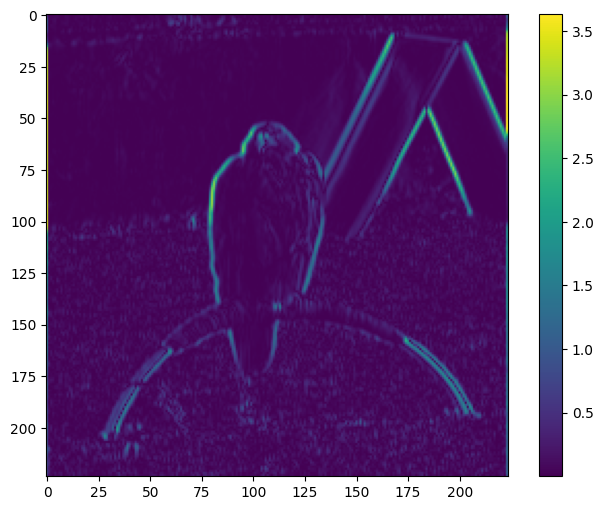

In [ ]:
kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

from scipy.signal import convolve2d
# img_gray = color.rgb2gray(img_raw)
feature_map = convolve2d(img_raw, kernel, mode = 'same')
# feature_map = convolve2d(img_gray, kernel, mode = 'same')

plt.figure(figsize = (8, 6))
plt.imshow(np.absolute(feature_map), cmap="viridis")
plt.colorbar()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from skimage import data, transform
import numpy as np
import matplotlib.pyplot as plt

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step


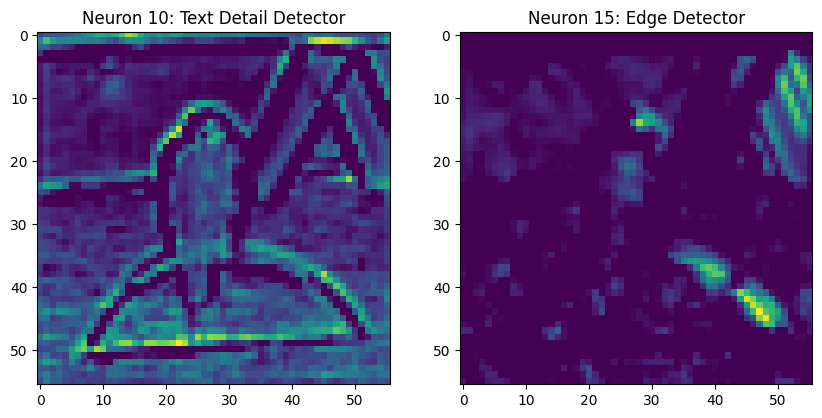

In [ ]:
model  = VGG16(weights = 'imagenet', include_top = False)

img_raw = data.eagle()
eagle_resized = transform.resize(img_raw, (224, 224))

# Convert the grayscale image to a 3-channel image
# VGG16 expects input shape (batch, height, width, channels), with channels=3
eagle_resized_rgb = np.stack([eagle_resized, eagle_resized, eagle_resized], axis=-1)

x = np.expand_dims(eagle_resized_rgb*255, axis = 0)
x = preprocess_input(x)

mid_layer_model = tf.keras.Model(inputs = model.input, outputs = model.get_layer('block3_conv1').output)
mid_features = mid_layer_model.predict(x)

# Visualize the 10th and 15th filters (neurons)
fig, ax = plt.subplots(1, 2, figsize = (10, 10))
ax[0].imshow(mid_features[0, :, :, 10], cmap = 'viridis')
ax[0].set_title('Neuron 10: Text Detail Detector')
ax[1].imshow(mid_features[0, :, :, 15], cmap = 'viridis')
ax[1].set_title('Neuron 15: Edge Detector')
plt.show()

# Extract the final convolution layer (Block 5, Conv 3)

In [ ]:
deep_layer_model = tf.keras.Model(inputs = model.input, outputs = model.get_layer('block5_conv3').output)

In [ ]:
deep_features = deep_layer_model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 725ms/step


## In deep layers, many filters will be blank, but some will "glow" intensely
## On specific parts of the eagles's image

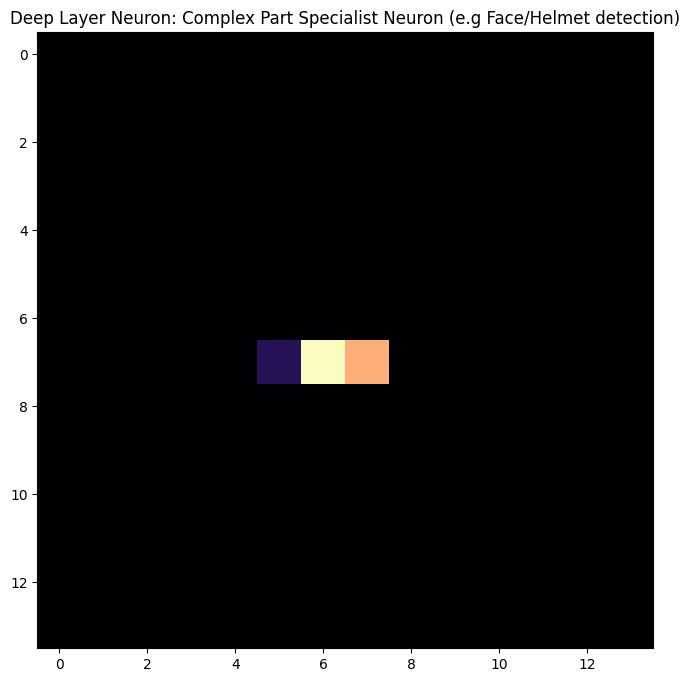

In [ ]:
plt.figure(figsize= (8,8))
plt.imshow(deep_features[0, :, :, 4], cmap = 'magma')
plt.title('Deep Layer Neuron: Complex Part Specialist Neuron (e.g Face/Helmet detection)')
plt.show()